In [1]:
import sys
#sys.path.insert(0, '../src')
sys.path.append('../')
# Import packages
import pandas as pd
import numpy as np
import matplotlib
from matplotlib import dates as mdates
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from pmdarima import auto_arima
import pmdarima as pm
#from scipy.stats import boxcox
#from scipy.special import inv_boxcox

from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from src.busy_airports.baselines import NaiveSeasonalWithDrift, TripleExponentialSmoothing
from src.busy_airports.preprocessing import load_data, retrieve_airport_data
from busy_airports.data_splits import make_rolling_splits, make_rolling_splits_weekly
from src.busy_airports.metrics import evaluate_forecast

In [3]:
#Import and process weekly data for Chicago airport
data = load_data("../data/tsa-throughput-data-complete.csv")
data_ord_w = retrieve_airport_data(data, "ORD", frequency="W")

In [4]:
#Let's visualize the weekly throughput data for Chicago O'Hare
px.line(data_ord_w, x='datetime', y='total_passenger_throughput', 
        labels={'total_passenger_throughput': 'Weekly Throughput'},
        template="simple_white", 
        title='Weekly Throughput at ORD',
        height=500, width=1000).update_layout(font=dict(size=14), title_x=0.5).show()

In [5]:
data_ord_w_train= data_ord_w[data_ord_w.index <= 181]
splits = make_rolling_splits_weekly(data_ord_w_train, date_col='datetime', n_splits=5, step_weeks=13)

data_ord_w_train_train = data_ord_w_train.query("datetime < '2025-01-01'")
data_ord_w_train_test = data_ord_w_train.query("datetime >= '2025-01-01'")


Split 1: train → row 116 (2024-03-31) | test rows 117–129 (2024-04-07 → 2024-06-30) (13 weeks)
Split 2: train → row 129 (2024-06-30) | test rows 130–142 (2024-07-07 → 2024-09-29) (13 weeks)
Split 3: train → row 142 (2024-09-29) | test rows 143–155 (2024-10-06 → 2024-12-29) (13 weeks)
Split 4: train → row 155 (2024-12-29) | test rows 156–168 (2025-01-05 → 2025-03-30) (13 weeks)
Split 5: train → row 168 (2025-03-30) | test rows 169–181 (2025-04-06 → 2025-06-29) (13 weeks)


In [12]:
from busy_airports.harmonic_model import fourier_features, time_index_feature


Minimum metrics:
  MSE:  (24, 3,741,741,220)
  MAE:  (2, 54,702)
  MAPE: (2, 0.09%)
  RMSE: (24, 60,970)


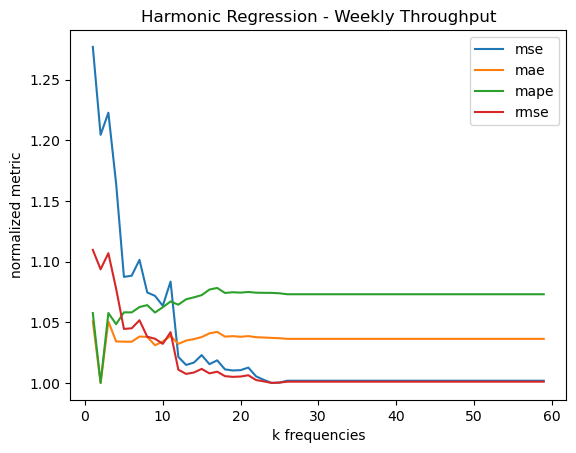

In [ ]:
results = []

for k_freq in range(1, 60):
    # Determine Fourier features for the given number of frequencies
    ord_weekly_X = fourier_features(data_ord_w_train['week'], m=52, k=k_freq)
    
    k_metrics = []

    for i, (train_idx, test_idx) in enumerate(splits, start = 1):
        X_train = ord_weekly_X[train_idx]
        X_test  = ord_weekly_X[test_idx]
        y_train = data_ord_w_train.iloc[train_idx].total_passenger_throughput
        y_test  = data_ord_w_train.iloc[test_idx].total_passenger_throughput

        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        metrics = {}
        metrics['split'] = i
        metrics['mse'] = mean_squared_error(y_test, y_pred)
        metrics['mae'] = mean_absolute_error(y_test, y_pred)
        metrics['mape'] = mean_absolute_percentage_error(y_test, y_pred)
        metrics['rmse'] = root_mean_squared_error(y_test, y_pred)
        k_metrics.append(metrics)
    
    metrics_df = pd.DataFrame(k_metrics).set_index('split')
    mean_metrics = {}
    mean_metrics['k_freq'] = k_freq
    mean_metrics['mse']  = metrics_df['mse'].mean()
    mean_metrics['mae']  = metrics_df['mae'].mean()
    mean_metrics['mape'] = metrics_df['mape'].mean()
    mean_metrics['rmse'] = metrics_df['rmse'].mean()
    results.append(mean_metrics)

results_df = pd.DataFrame(results).set_index('k_freq')

print(f"\nMinimum metrics:")
print(f"  MSE:  ({results_df['mse'].idxmin()}, {results_df['mse'].min():,.0f})")
print(f"  MAE:  ({results_df['mae'].idxmin()}, {results_df['mae'].min():,.0f})")
print(f"  MAPE: ({results_df['mape'].idxmin()}, {results_df['mape'].min():.2f}%)")
print(f"  RMSE: ({results_df['rmse'].idxmin()}, {results_df['rmse'].min():,.0f})")

# Rescale all metrics based on their minumum value
results_df = results_df / results_df.min()
results_df.plot()
plt.title('Harmonic Regression - Weekly Throughput')
plt.xlabel('k frequencies')
plt.ylabel('normalized metric')
plt.legend()
plt.show()


Minimum metrics:
  MSE:  (25, 843,220,603)
  MAE:  (25, 22,437)
  MAPE: (25, 0.04%)
  RMSE: (24, 27,404)


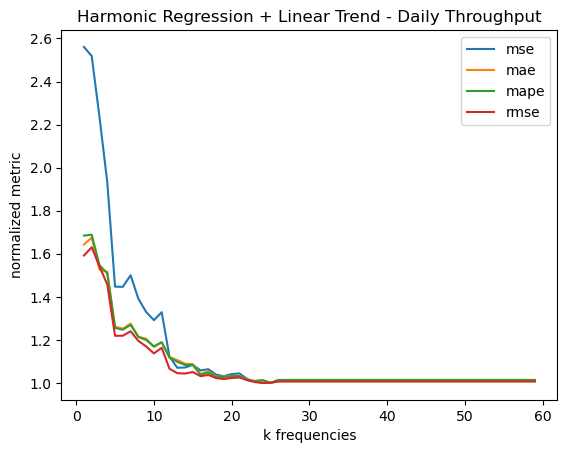

In [15]:
# We repeat the same process with the linear trend as well
results = []

for k_freq in range(1, 60):
    # Determine Fourier features for the given number of frequencies
    ord_weekly_ff = fourier_features(data_ord_w_train['week'], m=52, k=k_freq)
    ord_weekly_ti = time_index_feature(data_ord_w_train['week'])
    ord_weekly_X = np.column_stack([ord_weekly_ff, ord_weekly_ti])
    
    k_metrics = []

    for i, (train_idx, test_idx) in enumerate(splits, start = 1):
        X_train = ord_weekly_X[train_idx]
        X_test  = ord_weekly_X[test_idx]
        y_train = data_ord_w_train.iloc[train_idx].total_passenger_throughput
        y_test  = data_ord_w_train.iloc[test_idx].total_passenger_throughput

        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        metrics = {}
        metrics['split'] = i
        metrics['mse'] = mean_squared_error(y_test, y_pred)
        metrics['mae'] = mean_absolute_error(y_test, y_pred)
        metrics['mape'] = mean_absolute_percentage_error(y_test, y_pred)
        metrics['rmse'] = root_mean_squared_error(y_test, y_pred)
        k_metrics.append(metrics)
    
    metrics_df = pd.DataFrame(k_metrics).set_index('split')
    mean_metrics = {}
    mean_metrics['k_freq'] = k_freq
    mean_metrics['mse']  = metrics_df['mse'].mean()
    mean_metrics['mae']  = metrics_df['mae'].mean()
    mean_metrics['mape'] = metrics_df['mape'].mean()
    mean_metrics['rmse'] = metrics_df['rmse'].mean()
    results.append(mean_metrics)

results_df = pd.DataFrame(results).set_index('k_freq')

print(f"\nMinimum metrics:")
print(f"  MSE:  ({results_df['mse'].idxmin()}, {results_df['mse'].min():,.0f})")
print(f"  MAE:  ({results_df['mae'].idxmin()}, {results_df['mae'].min():,.0f})")
print(f"  MAPE: ({results_df['mape'].idxmin()}, {results_df['mape'].min():.2f}%)")
print(f"  RMSE: ({results_df['rmse'].idxmin()}, {results_df['rmse'].min():,.0f})")

# Rescale all metrics based on their minumum value
results_df = results_df / results_df.min()
results_df.plot()
plt.title('Harmonic Regression + Linear Trend - Daily Throughput')
plt.xlabel('k frequencies')
plt.ylabel('normalized metric')
plt.legend()
plt.show()

In [17]:
# Like before, we first test it out on just one split
ord_weekly_X = fourier_features(data_ord_w_train['week'], m=52, k=25)

X_train = ord_weekly_X[splits[1][0]]
X_test  = ord_weekly_X[splits[1][1]]
y_train = data_ord_w_train.iloc[splits[1][0]].total_passenger_throughput
y_test  = data_ord_w_train.iloc[splits[1][1]].total_passenger_throughput

arima_model = pm.auto_arima(
    y_train,
    X=X_train,
    seasonal=True, m=52,
    #d=1, D=0,
    # start_p=0, max_p=1,
    # start_q=0, max_q=1,
    # start_P=0, max_P=1,
    # start_Q=0, max_Q=1,
    stepwise=True,
    trace=True
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[52] intercept   : AIC=inf, Time=16.25 sec
 ARIMA(0,1,0)(0,0,0)[52] intercept   : AIC=2931.213, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[52] intercept   : AIC=2936.987, Time=2.74 sec
 ARIMA(0,1,1)(0,0,1)[52] intercept   : AIC=2942.996, Time=2.91 sec
 ARIMA(0,1,0)(0,0,0)[52]             : AIC=3429.199, Time=0.02 sec
 ARIMA(0,1,0)(1,0,0)[52] intercept   : AIC=2932.383, Time=1.96 sec
 ARIMA(0,1,0)(0,0,1)[52] intercept   : AIC=2932.298, Time=1.64 sec
 ARIMA(0,1,0)(1,0,1)[52] intercept   : AIC=2933.516, Time=6.08 sec
 ARIMA(1,1,0)(0,0,0)[52] intercept   : AIC=2936.054, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[52] intercept   : AIC=2942.420, Time=0.12 sec
 ARIMA(1,1,1)(0,0,0)[52] intercept   : AIC=2938.734, Time=0.39 sec

Best model:  ARIMA(0,1,0)(0,0,0)[52] intercept
Total fit time: 32.200 seconds


In [26]:
# Best model:  ARIMA(0,1,0)(0,0,0)[52] intercept
#
# Now we cross-validate along every fold and compare with the baseline models

# Determine Fourier features for the optimized number of frequencies
ord_weekly_X = fourier_features(data_ord_w_train['week'], m=52, k=25)

results = []

for i, (train_idx, test_idx) in enumerate(splits, start = 1):
    X_train = ord_weekly_X[train_idx]
    X_test  = ord_weekly_X[test_idx]
    y_train = data_ord_w_train.iloc[train_idx].total_passenger_throughput
    y_test  = data_ord_w_train.iloc[test_idx].total_passenger_throughput

    # Establish baseline models and Harmonic model to compare
    nswd_year_model = NaiveSeasonalWithDrift(season_length=52)
    #nswd_month_model = NaiveSeasonalWithDrift(season_length=4)
    exps_year_model = TripleExponentialSmoothing(season_length=52)
    #exps_month_model = TripleExponentialSmoothing(season_length=4)
    harmonic_model = pm.ARIMA(order=(0,1,0), 
                              seasonal_order=(0,0,0,52), 
                              with_intercept=False)

    # Fit models
    nswd_year_model.fit(y_train)
    #nswd_month_model.fit(y_train)
    exps_year_model.fit(y_train)
    #exps_month_model.fit(y_train)
    harmonic_model.fit(y_train, X_train)

    # Evaluate models
    nwsd_year_pred = nswd_year_model.forecast(h=len(y_test))
    #nwsd_month_pred = nswd_month_model.forecast(h=len(y_test))
    exps_year_pred = exps_year_model.forecast(h=len(y_test))
    #exps_month_pred = exps_month_model.forecast(h=len(y_test))
    harmonic_pred = harmonic_model.predict(n_periods=len(y_test), X=X_test)

    metrics = {}
    metrics['model'] = 'nswd'
    metrics['split'] = i
    #metrics['mse'] = mean_squared_error(y_test, nwsd_year_pred)
    metrics['mae'] = mean_absolute_error(y_test, nwsd_year_pred)
    metrics['mape'] = mean_absolute_percentage_error(y_test, nwsd_year_pred)
    metrics['rmse'] = root_mean_squared_error(y_test, nwsd_year_pred)
    results.append(metrics)

    metrics = {}
    metrics['model'] = 'exps'
    metrics['split'] = i
    #metrics['mse'] = mean_squared_error(y_test, exps_year_pred)
    metrics['mae'] = mean_absolute_error(y_test, exps_year_pred)
    metrics['mape'] = mean_absolute_percentage_error(y_test, exps_year_pred)
    metrics['rmse'] = root_mean_squared_error(y_test, exps_year_pred)
    results.append(metrics)


    metrics = {}
    metrics['model'] = 'harmonic'
    metrics['split'] = i
    #metrics['mse'] = mean_squared_error(y_test, harmonic_pred)
    metrics['mae'] = mean_absolute_error(y_test, harmonic_pred)
    metrics['mape'] = mean_absolute_percentage_error(y_test, harmonic_pred)
    metrics['rmse'] = root_mean_squared_error(y_test, harmonic_pred)
    results.append(metrics)

    print(f"Finished split {i}")

cv_means = pd.DataFrame(results).groupby(by=["model"])[["mae", "mape", "rmse"]].mean()

print(f"\nCV Results:")
# print(f"  MSE: {cv_means['mse']:,.0f}")
# print(f"  MAPE: {cv_means['mape']:.2f}%")
# print(f"  RMSE: {cv_means['rmse']:,.0f}")
print(cv_means)

Finished split 1
Finished split 2
Finished split 3
Finished split 4
Finished split 5

CV Results:
                   mae      mape          rmse
model                                         
exps      22981.790974  0.041143  27170.722062
harmonic  24442.757824  0.043241  29386.615448
nswd      23727.892308  0.041210  27780.543159


In [19]:
from busy_airports.models import HarmonicARIMA
model = HarmonicARIMA(harmonic_m=52, harmonic_k=25, arima_order=(0,1,0), seasonal_order=(0,0,0,52))

In [20]:
model.fit(ts_index=data_ord_w_train_train['week'], 
          ts_data=data_ord_w_train_train['total_passenger_throughput'])

<class 'statsmodels.iolib.summary.Summary'>
"""
                                   SARIMAX Results                                    
======================================================================================
Dep. Variable:     total_passenger_throughput   No. Observations:                  156
Model:                       SARIMAX(0, 1, 0)   Log Likelihood               -1714.838
Date:                        Thu, 19 Mar 2026   AIC                           3533.675
Time:                                22:00:00   BIC                           3691.933
Sample:                                     0   HQIC                          3597.956
                                        - 156                                         
Covariance Type:                          opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   1073.7053   2538.867      0.423      0.672   -3902.383    6049.794
x1         -2.208e+04   3.23e+04     -0.683      0.494   -8.54e+04    4.12e+04
x2         -6.932e+04   2.49e+04     -2.787      0.005   -1.18e+05   -2.06e+04
x3         -1.793e+04   1.42e+04     -1.260      0.208   -4.58e+04    9964.187
x4          -245.3568   1.55e+04     -0.016      0.987   -3.05e+04       3e+04
x5         -1.163e+04   9584.573     -1.213      0.225   -3.04e+04    7154.796
x6         -9744.7844   9612.563     -1.014      0.311   -2.86e+04    9095.492
x7         -1.126e+04   6932.716     -1.624      0.104   -2.48e+04    2332.531
x8           1.23e+04   7613.817      1.616      0.106   -2618.136    2.72e+04
x9         -2658.9033   5803.581     -0.458      0.647    -1.4e+04    8715.907
x10         2.371e+04   6166.681      3.845      0.000    1.16e+04    3.58e+04
x11        -2436.1103   5172.735     -0.471      0.638   -1.26e+04    7702.265
x12        -1683.4893   4957.733     -0.340      0.734   -1.14e+04    8033.489
x13         3384.3994   4377.348      0.773      0.439   -5195.045     1.2e+04
x14         3657.6181   4373.288      0.836      0.403   -4913.868    1.22e+04
x15        -6052.4336   4056.501     -1.492      0.136    -1.4e+04    1898.163
x16         4499.4287   3662.009      1.229      0.219   -2677.978    1.17e+04
x17         8101.2176   3482.938      2.326      0.020    1274.784    1.49e+04
x18         1.093e+04   3426.373      3.191      0.001    4216.737    1.76e+04
x19         2084.1742   3134.124      0.665      0.506   -4058.597    8226.945
x20         9069.3443   3140.730      2.888      0.004    2913.627    1.52e+04
x21        -2702.1372   3084.823     -0.876      0.381   -8748.279    3344.004
x22         1903.7464   2481.798      0.767      0.443   -2960.489    6767.981
x23        -1.237e+04   2694.613     -4.591      0.000   -1.77e+04   -7090.742
x24        -2233.2526   2627.018     -0.850      0.395   -7382.114    2915.609
x25         -399.0749   2532.914     -0.158      0.875   -5363.494    4565.345
x26         7149.4210   2499.316      2.861      0.004    2250.851     1.2e+04
x27         5963.4823   2285.911      2.609      0.009    1483.179    1.04e+04
x28         3484.0400   2466.730      1.412      0.158   -1350.662    8318.742
x29          -12.3330   1956.209     -0.006      0.995   -3846.433    3821.767
x30        -1014.1875   2478.236     -0.409      0.682   -5871.441    3843.066
x31        -3678.1444   2190.986     -1.679      0.093   -7972.399     616.110
x32         4816.8702   2167.831      2.222      0.026     568.000    9065.740
x33          213.6965   1981.870      0.108      0.914   -3670.698    4098.091
x34         1714.5692   2105.269      0.814      0.415   -2411.682    5840.820
x35         2365.1710   1918.743      1.233      0.218   -1395.497    6125.839
x36         4262.4132   2094.579      2.035      0.042     157.113    8367.713
x37      

In [21]:
y_pred = model.forecast(ts_index=data_ord_w_train_test['week'])
y_conf_int = model.conf_int(ts_index=data_ord_w_train_test['week'])

In [23]:
def plot_forecasts(forecasts: list[float], title: str, conf_int=None, last_n: int = None) -> None:
    """Function to plot the forecasts with optional 95% confidence interval band."""
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=data_ord_w_train_train['datetime'], y=data_ord_w_train_train['total_passenger_throughput'], name='Train'))
    fig.add_trace(go.Scatter(x=data_ord_w_train_test['datetime'], y=data_ord_w_train_test['total_passenger_throughput'], name='Test'))
    fig.add_trace(go.Scatter(x=data_ord_w_train_test['datetime'], y=forecasts, name='Forecast'))
    if conf_int is not None:
        upper = np.array(conf_int)[:, 1]
        lower = np.array(conf_int)[:, 0]
        fig.add_trace(go.Scatter(x=data_ord_w_train_test['datetime'], y=upper, line=dict(width=0), showlegend=False))
        fig.add_trace(go.Scatter(x=data_ord_w_train_test['datetime'], y=lower, fill='tonexty',
                                 fillcolor='rgba(68,114,196,0.2)', line=dict(width=0), name='95% CI'))

    xaxis = {}
    if last_n is not None:
        all_dates = pd.concat([data_ord_w_train['datetime'], data_ord_w_train_test['datetime']])
        xaxis['range'] = [all_dates.iloc[-last_n], all_dates.iloc[-1]]

    fig.update_layout(template="simple_white", font=dict(size=18), title_text=title,
                      width=1000, title_x=0.5, height=600, xaxis_title='Date',
                      yaxis_title='Passengers', xaxis=xaxis)
    return fig.show()

# Show only last 100 weeks
plot_forecasts(y_pred, 'Passenger Throughput at ORD', conf_int=y_conf_int, last_n=len(data_ord_w_train_train))